# <center> **PROJECT-3. EDA + Feature Engineering**

Импортируем необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
import statistics
import re
import ast
from collections import Counter

from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели 
from sklearn.model_selection import train_test_split 

import category_encoders as ce # импорт для работы с кодировщиком
from sklearn.feature_selection import chi2 # хи-квадрат

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

from sklearn import preprocessing # для нормализации, стандартизации

import matplotlib # Для графиков
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.style.use('ggplot')

In [81]:
# Фиксируем RANDOM_SEED, чтобы эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [82]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

In [83]:
# Скачаем наши данные из соревнования

df_train = pd.read_csv('data/hotels_train.csv') # датасет для обучения
df_test = pd.read_csv('data/hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv('data/submission.csv') # самбмишн

In [84]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [85]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [86]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [87]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


In [88]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [89]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [90]:
# Для корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

data = pd.concat([df_test, df_train], ignore_index=True) # объединяем

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515738 non-null  object 
 1   additional_number_of_scoring                515738 non-null  int64  
 2   review_date                                 515738 non-null  object 
 3   average_score                               515738 non-null  float64
 4   hotel_name                                  515738 non-null  object 
 5   reviewer_nationality                        515738 non-null  object 
 6   negative_review                             515738 non-null  object 
 7   review_total_negative_word_counts           515738 non-null  int64  
 8   total_number_of_reviews                     515738 non-null  int64  
 9   positive_review                             515738 non-null  object 
 

### 1. Первичный анализ данных

Первоначальная версия датасета содержит 17 полей со следующей информацией:
* hotel_address — адрес отеля;
* review_date — дата, когда рецензент разместил соответствующий отзыв;
* average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
* hotel_name — название отеля;
* reviewer_nationality — страна рецензента;
* negative_review — отрицательный отзыв, который рецензент дал отелю;
* review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
* positive_review — положительный отзыв, который рецензент дал отелю;
* review_total_positive_word_counts — общее количество слов в положительном отзыве.
* reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
* total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
* total_number_of_reviews — общее количество действительных отзывов об отеле;
* tags — теги, которые рецензент дал отелю;
* days_since_review — количество дней между датой проверки и датой очистки;
* additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* lat — географическая широта отеля;
* lng — географическая долгота отеля.

In [13]:
data.shape

(515738, 18)

---

### 2. Очистка данных

> Проверим наличие пропусков

In [92]:
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

lat    0.633655
lng    0.633655
dtype: float64

In [93]:
import time
from opencage.geocoder import OpenCageGeocode
from requests.exceptions import RequestException

key = "9e91558da04f4dd58121c6ea3ac31033"
geocoder = OpenCageGeocode(key)

# Находим строки с пропущенными координатами
missing_coords = data[data['lat'].isna() | data['lng'].isna()]
total_missing = len(missing_coords)


# Получаем уникальные адреса и сохраняем индексы всех строк с каждым адресом
unique_addresses = {}
for idx, row in missing_coords.iterrows():
    address = row['hotel_address']
    if address not in unique_addresses:
        unique_addresses[address] = []
    unique_addresses[address].append(idx)

print(f"Найдено {total_missing} отелей с пропущенными координатами.")
print(f"Из них уникальных адресов: {len(unique_addresses)}")
print("Начинаю обработку уникальных адресов...")

processed_count = 0
success_count = 0


# Обрабатываем только уникальные адреса
for address, indices in unique_addresses.items():
    try:
        results = geocoder.geocode(address, no_annotations='1')
        if results and len(results):
            lat = results[0]['geometry']['lat']
            lng = results[0]['geometry']['lng']
            # Заполняем координаты для ВСЕХ строк с этим адресом
            for idx in indices:
                data.loc[idx, 'lat'] = lat
                data.loc[idx, 'lng'] = lng
            success_count += 1
            print(f"Успешно: {address} -> {lat}, {lng} (затронуто строк: {len(indices)})")
        else:
            print(f"Адрес не найден: {address}")
        processed_count += 1
        time.sleep(1)  # Рекомендованная пауза
    except RequestException as e:
        print(f"Ошибка сети для адреса {address}: {e}")
        time.sleep(10)
    except Exception as e:
        print(f"Неожиданная ошибка для адреса {address}: {e}")
        time.sleep(10)

# Проверка результата после обработки
remaining_missing = data[data['lat'].isna() | data['lng'].isna()]
remaining_count = len(remaining_missing)

print("\n" + "="*50)
print("РЕЗУЛЬТАТ ОБРАБОТКИ:")
print(f"Всего строк с пропусками: {total_missing}")
print(f"Уникальных адресов для обработки: {len(unique_addresses)}")
print(f"Обработано уникальных адресов: {processed_count}")
print(f"Успешно геокодировано: {success_count}")
print(f"Осталось незаполненных: {remaining_count}")


if remaining_count == 0:
    print("\n✅ Отлично! Все пропуски успешно заполнены.")
else:
    print(f"\n⚠️ Осталось {remaining_count} строк с незаполненными координатами.")
    print("Возможно, некоторые адреса не были найдены геокодером.")

print("Обработка завершена!")

Найдено 3268 отелей с пропущенными координатами.
Из них уникальных адресов: 17
Начинаю обработку уникальных адресов...
Успешно: W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria -> 48.2333, 16.35 (затронуто строк: 389)
Успешно: Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria -> 48.2333, 16.35 (затронуто строк: 93)
Успешно: 23 Rue Damr mont 18th arr 75018 Paris France -> 48.887354, 2.345491 (затронуто строк: 55)
Успешно: Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria -> 48.2167, 16.35 (затронуто строк: 658)
Успешно: Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria -> 48.2167, 16.4 (затронуто строк: 563)
Успешно: Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria -> 48.2167, 16.35 (затронуто строк: 57)
Успешно: Bail n 4 6 Eixample 08010 Barcelona Spain -> 41.3888, 2.159 (затронуто строк: 146)
Успешно: Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria -> 48.1981, 16.3948 (затронуто строк: 245)
Успешно: 4 rue de la P pini re 8th arr 75008 Paris France 

In [16]:
data.nunique(dropna=False)

hotel_address                                   1493
additional_number_of_scoring                     480
review_date                                      731
average_score                                     34
hotel_name                                      1492
reviewer_nationality                             227
negative_review                               330011
review_total_negative_word_counts                402
total_number_of_reviews                         1142
positive_review                               412601
review_total_positive_word_counts                365
total_number_of_reviews_reviewer_has_given       198
tags                                           55242
days_since_review                                731
lat                                             1480
lng                                             1481
sample                                             2
reviewer_score                                    38
dtype: int64

> Проверим наличие выбросов для числовых признаков

In [17]:
data['additional_number_of_scoring'].describe()

count    515738.000000
mean        498.081836
std         500.538467
min           1.000000
25%         169.000000
50%         341.000000
75%         660.000000
max        2682.000000
Name: additional_number_of_scoring, dtype: float64

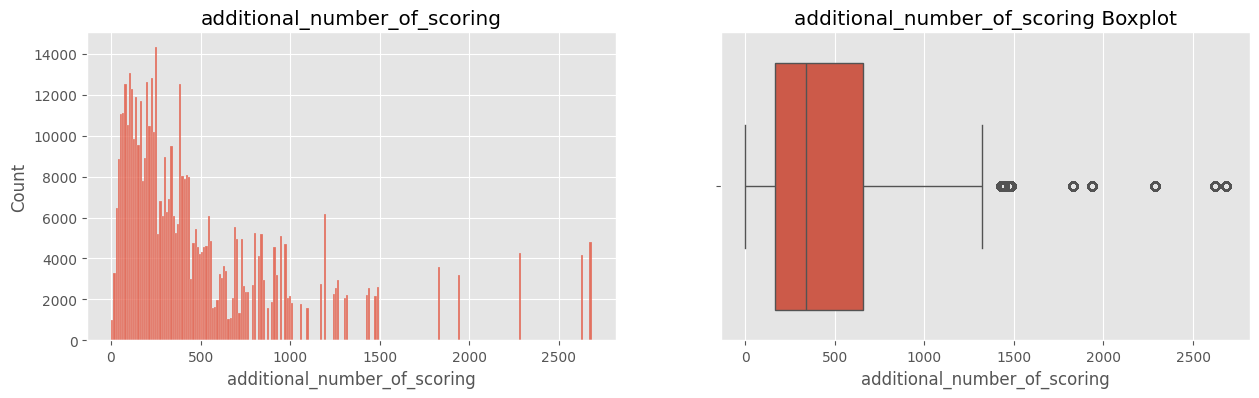

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='additional_number_of_scoring', ax=axes[0]);
histplot.set_title('additional_number_of_scoring');
boxplot = sns.boxplot(data=data, x='additional_number_of_scoring', ax=axes[1]);
boxplot.set_title('additional_number_of_scoring Boxplot');

Мы видим большое количество выбросов. В логарифмическом масштабе признак имеет подобие нормального распределения

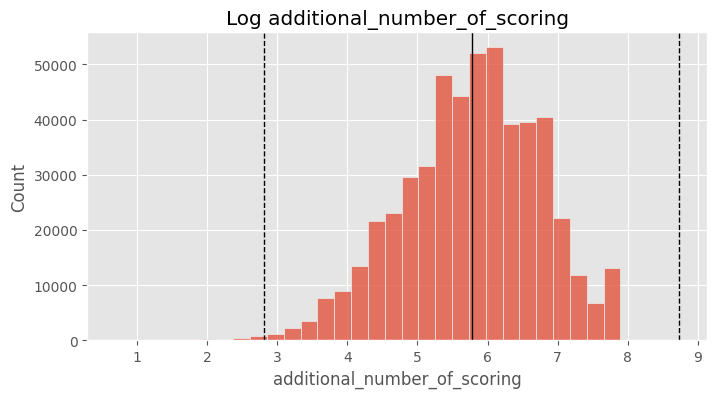

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_feat = np.log(data['additional_number_of_scoring'] + 1)
histplot = sns.histplot(log_feat, bins=30, ax=ax)
histplot.axvline(log_feat.mean(), color='k', lw=1)
histplot.axvline(log_feat.mean()+ 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.axvline(log_feat.mean()- 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.set_title('Log additional_number_of_scoring');

In [21]:
# Коэффициент ассиметрии:
print(log_feat.skew())

-0.27745513967913243


Так как мы готовим данные для модели, в условии сказано не удалять строки, поэтому мы не будем количественно оценивать и искать выбросы (метод 3-х сигм и др.)

---

In [22]:
data['average_score'].describe()

count    515738.000000
mean          8.397487
std           0.548048
min           5.200000
25%           8.100000
50%           8.400000
75%           8.800000
max           9.800000
Name: average_score, dtype: float64

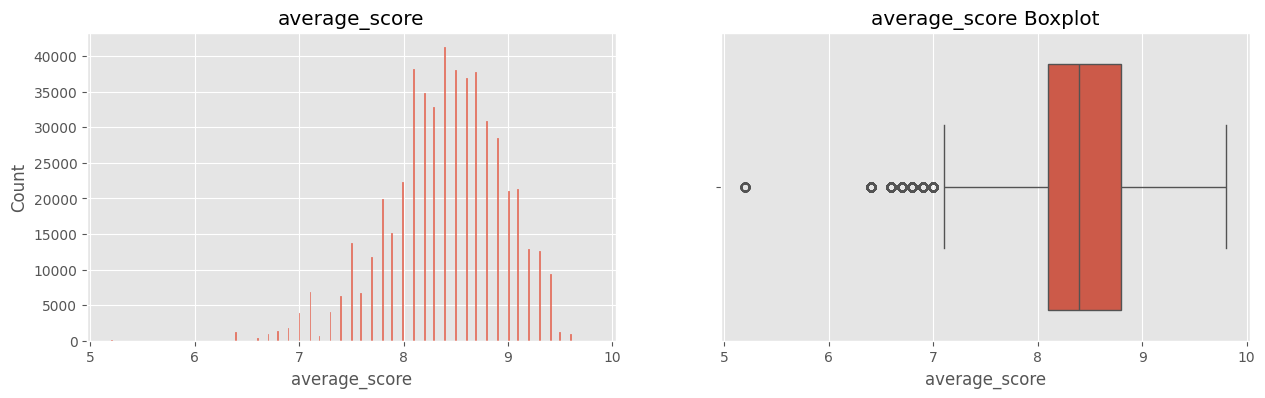

In [271]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='average_score', ax=axes[0]);
histplot.set_title('average_score');
boxplot = sns.boxplot(data=data, x='average_score', ax=axes[1]);
boxplot.set_title('average_score Boxplot');

---

In [272]:
data['review_total_negative_word_counts'].describe()

count    515738.000000
mean         18.539450
std          29.690831
min           0.000000
25%           2.000000
50%           9.000000
75%          23.000000
max         408.000000
Name: review_total_negative_word_counts, dtype: float64

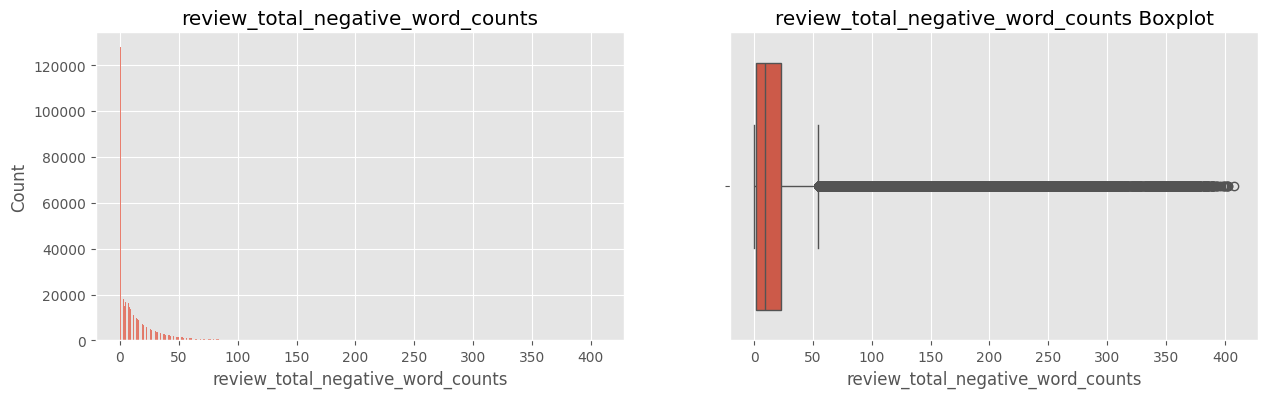

In [273]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='review_total_negative_word_counts', ax=axes[0]);
histplot.set_title('review_total_negative_word_counts');
boxplot = sns.boxplot(data=data, x='review_total_negative_word_counts', ax=axes[1]);
boxplot.set_title('review_total_negative_word_counts Boxplot');

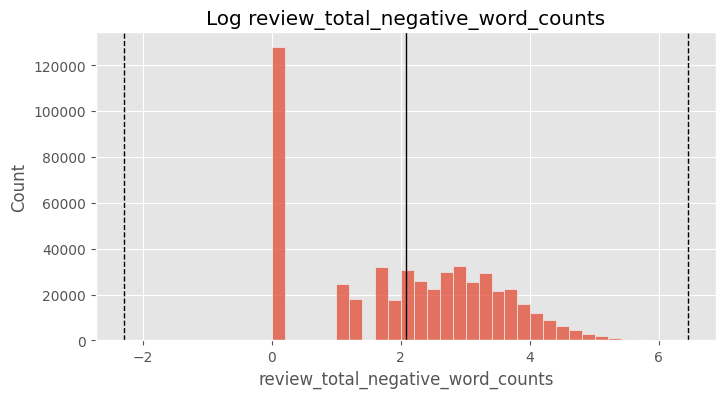

In [274]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_feat = np.log(data['review_total_negative_word_counts'] + 1)
histplot = sns.histplot(log_feat, bins=30, ax=ax)
histplot.axvline(log_feat.mean(), color='k', lw=1)
histplot.axvline(log_feat.mean()+ 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.axvline(log_feat.mean()- 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.set_title('Log review_total_negative_word_counts');

---

In [275]:
data['total_number_of_reviews'].describe()

count    515738.000000
mean       2743.743944
std        2317.464868
min          43.000000
25%        1161.000000
50%        2134.000000
75%        3613.000000
max       16670.000000
Name: total_number_of_reviews, dtype: float64

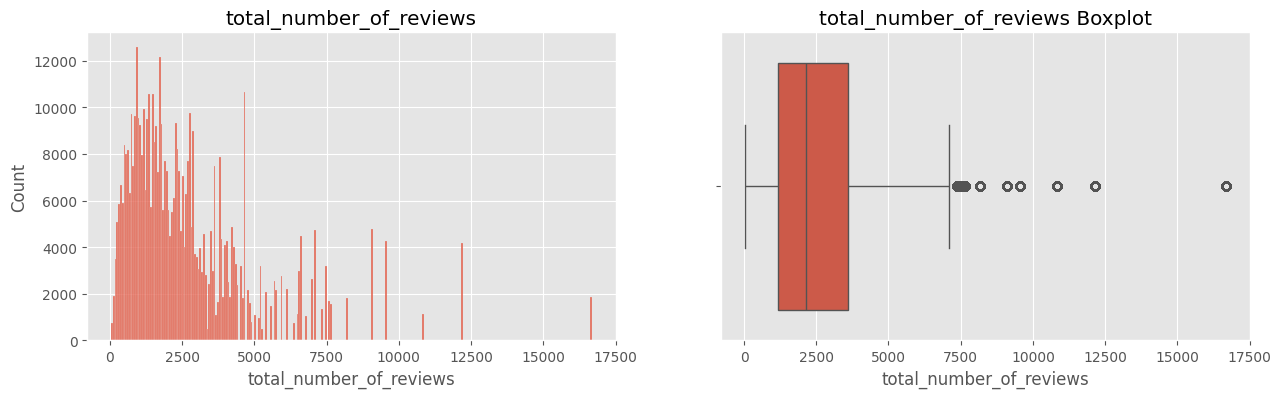

In [276]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='total_number_of_reviews', ax=axes[0]);
histplot.set_title('total_number_of_reviews');
boxplot = sns.boxplot(data=data, x='total_number_of_reviews', ax=axes[1]);
boxplot.set_title('total_number_of_reviews Boxplot');

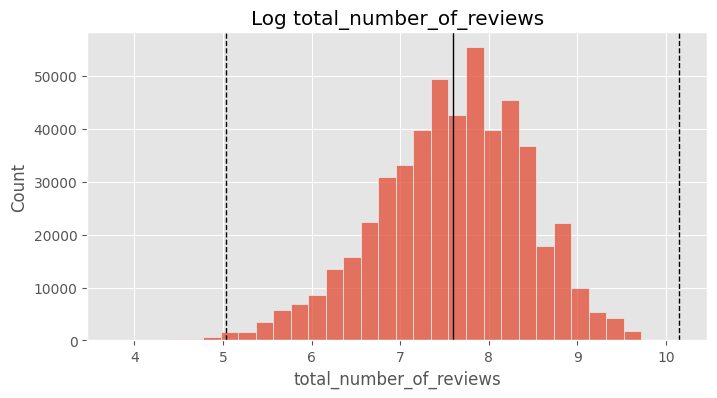

In [277]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_feat = np.log(data['total_number_of_reviews'] + 1)
histplot = sns.histplot(log_feat, bins=30, ax=ax)
histplot.axvline(log_feat.mean(), color='k', lw=1)
histplot.axvline(log_feat.mean()+ 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.axvline(log_feat.mean()- 3 * log_feat.std(), color='k', ls='--', lw=1)
histplot.set_title('Log total_number_of_reviews');

---

In [278]:
data['review_total_positive_word_counts'].describe()

count    515738.000000
mean         17.776458
std          21.804185
min           0.000000
25%           5.000000
50%          11.000000
75%          22.000000
max         395.000000
Name: review_total_positive_word_counts, dtype: float64

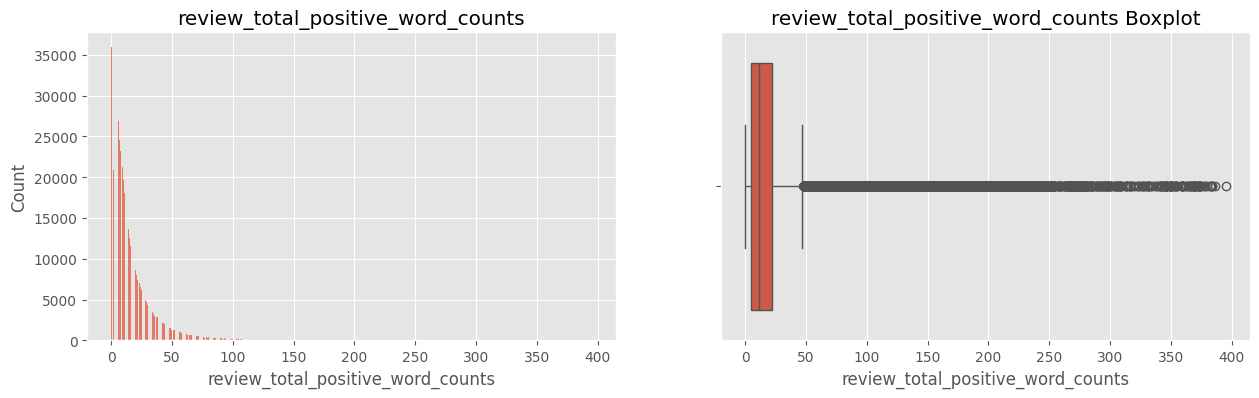

In [279]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='review_total_positive_word_counts', ax=axes[0]);
histplot.set_title('review_total_positive_word_counts');
boxplot = sns.boxplot(data=data, x='review_total_positive_word_counts', ax=axes[1]);
boxplot.set_title('review_total_positive_word_counts Boxplot');

---

In [280]:
data['total_number_of_reviews_reviewer_has_given'].describe()

count    515738.000000
mean          7.166001
std          11.040228
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max         355.000000
Name: total_number_of_reviews_reviewer_has_given, dtype: float64

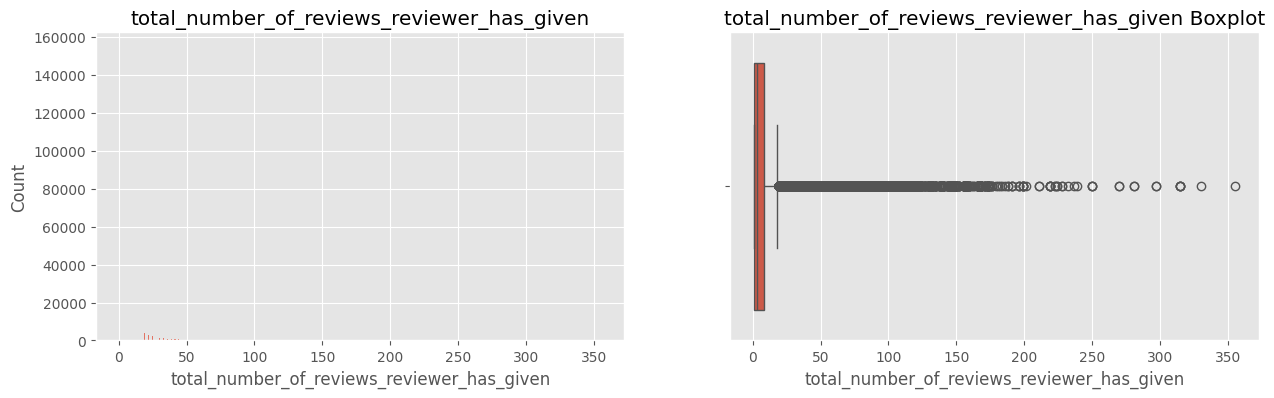

In [281]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='total_number_of_reviews_reviewer_has_given', ax=axes[0]);
histplot.set_title('total_number_of_reviews_reviewer_has_given');
boxplot = sns.boxplot(data=data, x='total_number_of_reviews_reviewer_has_given', ax=axes[1]);
boxplot.set_title('total_number_of_reviews_reviewer_has_given Boxplot');

---

## 3. Создание новых признаков

Из признака 'hotel_address' выделим город

In [94]:
data['city'] = data['hotel_address'].apply(lambda x: ' '.join(x.split(' ')[-5]) if x.split(' ')[-1] == 'Kingdom' else x.split(' ')[-2])

In [95]:
data['city'].value_counts()

city
L o n d o n    262301
Barcelona       60149
Paris           59928
Amsterdam       57214
Vienna          38939
Milan           37207
Name: count, dtype: int64

Из признака 'hotel_address' вытащим страну

In [96]:
data['country'] = data['hotel_address'].apply(lambda x: ' '.join(x.split(' ')[-2:]) if x.split(' ')[-1] == 'Kingdom' else x.split(' ')[-1])

In [97]:
data['country'].value_counts()

country
United Kingdom    262301
Spain              60149
France             59928
Netherlands        57214
Austria            38939
Italy              37207
Name: count, dtype: int64

In [98]:
# Удаляем первоначальный признак
data = data.drop('hotel_address', axis = 1)

---

In [99]:
# Признак - дата
data['review_date'] = pd.to_datetime(data['review_date'])

In [100]:
from datetime import datetime
def get_season(date_input):
  
    # Преобразование в datetime
    if isinstance(date_input, pd.Timestamp):
        date_obj = date_input.to_pydatetime()
    elif isinstance(date_input, datetime):
        date_obj = date_input
    elif isinstance(date_input, str):
        # Пробуем разные форматы
        for fmt in ['%Y-%m-%d %H:%M:%S', '%Y-%m-%d']:
            try:
                date_obj = datetime.strptime(date_input, fmt)
                break
            except ValueError:
                continue
        else:
            raise ValueError(f"Не удалось распознать формат даты: {date_input}")
    else:
        raise TypeError(f"Неподдерживаемый тип: {type(date_input)}")

    month = date_obj.month

    # Определение сезона
    season_map = {
        12: 'winter', 1: 'winter', 2: 'winter',
        3: 'spring', 4: 'spring', 5: 'spring',
        6: 'summer', 7: 'summer', 8: 'summer',
        9: 'autumn', 10: 'autumn', 11: 'autumn'
    }
    return season_map[month]

In [101]:
get_season('2016-12-12 00:00:00')

'winter'

Создадим признак - время года, когда был оставлен отзыв

In [102]:
data['season'] = data['review_date'].apply(get_season)

In [103]:
data['season'].value_counts()

season
summer    142886
spring    130483
autumn    122241
winter    120128
Name: count, dtype: int64

In [104]:
# Удаляем первоначальный признак
data = data.drop('review_date', axis = 1)

---

Посчитаем количество уникальных тегов в датасете

In [105]:
tag_list = []
for i in range(data.shape[0]):
    input_string = data['tags'].iloc[i]
    data_list = [item.strip() for item in ast.literal_eval(input_string)]
    for tag in data_list:
        if tag not in tag_list:
            tag_list.append(tag)
print(len(tag_list))

2428


Функция преобразования строки в список

In [106]:
def tags_to_list(string):
    input_string = string
    return([item.strip() for item in ast.literal_eval(input_string)])

In [107]:
# Применим функцию преобразования и сделаем признак Теги удобным для использования
data['tags']=data['tags'].apply(tags_to_list)

In [108]:
# Посчитаем общее количество опубликованных тегов и запишем их в teg_list
tag_list = []
for i in range(data.shape[0]):
    for tag in data['tags'].iloc[i]:
        tag_list.append(tag)
len(tag_list)

2356592

In [109]:
# С помощью счетчика найдем самый часто публикуемый тег, а также то, что тег 'Stayed 1 night' употреблялся чаще, чем 'Stayed 2 nights'
counter_tags = Counter(tag_list)
print(counter_tags.most_common(10))


[('Leisure trip', 417778), ('Submitted from a mobile device', 307640), ('Couple', 252294), ('Stayed 1 night', 193645), ('Stayed 2 nights', 133937), ('Solo traveler', 108545), ('Stayed 3 nights', 95821), ('Business trip', 82939), ('Group', 65392), ('Family with young children', 61015)]


In [110]:
# Получим список индексов записей, где количество тегов меньше 4
count = []
for i in range(data.shape[0]):
    if len(data['tags'].iloc[i]) < 4:
        count.append(i)
print(count)
print(len(count))
# 5592 строк, где тегов меньше 4

[8, 437, 450, 518, 703, 928, 1241, 1290, 1359, 1481, 1704, 1740, 2014, 2015, 2109, 2178, 2181, 2345, 2589, 2643, 2691, 2724, 2749, 2787, 2814, 2943, 2983, 3095, 3126, 3143, 3173, 3450, 3455, 3492, 3557, 3695, 3796, 3836, 3971, 4273, 4665, 4765, 4835, 4956, 5199, 5292, 5381, 5425, 5490, 5659, 5758, 5790, 5821, 5842, 5877, 5916, 5958, 5968, 5977, 5978, 5979, 6004, 6073, 6213, 6279, 6369, 6472, 6494, 6572, 6675, 6771, 6784, 6800, 7012, 7042, 7133, 7308, 7329, 7354, 7377, 7596, 7715, 7907, 8180, 8226, 8289, 8377, 8561, 8639, 8806, 8974, 9101, 9226, 9233, 9470, 9481, 9539, 9750, 9767, 9787, 9870, 9909, 9977, 10129, 10130, 10249, 10280, 10430, 10477, 10492, 10755, 10762, 10777, 11057, 11229, 11310, 11367, 11400, 11503, 11514, 11558, 11740, 11748, 11777, 12343, 12375, 12668, 12733, 12827, 12995, 13007, 13062, 13365, 13382, 13411, 13429, 13577, 13605, 13613, 13651, 13773, 13792, 13863, 13977, 14008, 14138, 14306, 14515, 14592, 14691, 14840, 14845, 14952, 15244, 15261, 15329, 15437, 15608, 1561

In [112]:
# Функция для поиска в тегах количества ночей пребывания в отеле
def staying_in(lst):
    regex = r'\d+'
    for tag in lst:
        if 'Stayed' in tag:
            match = re.search(regex, tag)
            if match:
                return int(match.group())
    return None

Создаем новый признак количества ночей пребывания в отеле

In [113]:
data['staying_in'] = data['tags'].apply(staying_in)

Новый признак - тип поездки

In [114]:
def type_of_trip(lst):
    for tag in lst:
        if 'Business' in tag:
            return 'Business trip'
        elif 'Leisure' in tag:
            return 'Leisure trip'

In [115]:
data['type_of_trip'] = data['tags'].apply(type_of_trip)

Признак Количество гостей

In [116]:
def guests(lst):
    for tag in lst:
        if 'Couple' in tag:
            return 'Couple'
        elif 'Solo ' in tag:
            return 'Solo traveler'
        elif 'young' in tag:
            return 'Family with young children'
        elif 'Group' in tag:
            return 'Group'
        elif 'older' in tag:
            return 'Family with older children'
        elif 'Travelers' in tag:
            return 'Travelers with friends'
        elif 'With a pet' in tag:
            return 'With a pet'

In [117]:
data['guests'] = data['tags'].apply(guests)

Создаем признак тип комнаты:

In [118]:
def roome_type(lst):
    for tag in lst:
        if 'Room' in tag:
            return tag
        elif 'rooms ' in tag:
            return tag
        elif 'Suite' in tag:
            return tag
        elif 'Double' in tag:
            return tag
        elif 'Guestroom' in tag:
            return tag
        elif 'Standard' in tag:
            return tag
        elif 'Studio' in tag:
            return tag

In [119]:
data['roome_type'] = data['tags'].apply(roome_type)

Создаем признак Отправки отзыва с мобильного телефона

In [120]:
def mobile_device(lst):
    return 1 if 'Submitted from a mobile device' in lst else 0

In [121]:
data['mobile_device'] = data['tags'].apply(mobile_device)

In [122]:
# Уаляем первоначальный признак 'tags'
data = data.drop('tags',axis = 1)

---

Выделим из признака 'days_since_review' число 

In [123]:
regex = '\d*' # регулярное выражение для нахождения чисел
data['days_since_review'] = data['days_since_review'].str.findall(regex).str.get(0)

In [124]:
data['days_since_review'] = data['days_since_review'].astype('int64')
data['days_since_review'].describe()

count    515738.000000
mean        354.441932
std         208.928124
min           0.000000
25%         175.000000
50%         353.000000
75%         527.000000
max         730.000000
Name: days_since_review, dtype: float64

---

Преобразуем с помощью модуля SentimentIntensityAnalyzer() отзывы в 3 категории - Позитивный, Нейтральный и Негативный

In [125]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import time
nltk.downloader.download('vader_lexicon')

sent_analyzer = SentimentIntensityAnalyzer()
def reviews(string):
    scores = sent_analyzer.polarity_scores(string)
    if scores['compound'] >= 0.05:
        return 'pozitive'
    elif scores['compound'] <= -0.05:
        return 'negativ'
    else:
        return 'neutral'

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [126]:
data['negative_review'] = data['negative_review'].apply(reviews)

In [127]:
data['negative_review'].value_counts()

negative_review
negativ     272782
neutral     141119
pozitive    101837
Name: count, dtype: int64

---

In [128]:
data['positive_review']=data['positive_review'].apply(reviews)

In [129]:
data['positive_review'].value_counts()

positive_review
pozitive    432479
neutral      76318
negativ       6941
Name: count, dtype: int64

---

## 4. Преобразование категориальных признаков

In [130]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 23 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515738 non-null  int64  
 1   average_score                               515738 non-null  float64
 2   hotel_name                                  515738 non-null  object 
 3   reviewer_nationality                        515738 non-null  object 
 4   negative_review                             515738 non-null  object 
 5   review_total_negative_word_counts           515738 non-null  int64  
 6   total_number_of_reviews                     515738 non-null  int64  
 7   positive_review                             515738 non-null  object 
 8   review_total_positive_word_counts           515738 non-null  int64  
 9   total_number_of_reviews_reviewer_has_given  515738 non-null  int64  
 

In [131]:
# Кодировка признака 'season' -  4 уникальных категории

encoder = ce.OneHotEncoder(cols=['season'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data['season'])
data = pd.concat([data, type_bin], axis=1)

In [132]:
# Удаляем первоначальный признак 'season'
data = data.drop('season',axis = 1)

In [133]:
# Кодировка признака 'negative_review' -  4 уникальных категории

encoder = ce.OneHotEncoder(cols=['negative_review'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data['negative_review'])
data = pd.concat([data, type_bin], axis=1)

In [134]:
# Удаляем первоначальный признак 'negative_review'
data = data.drop('negative_review',axis = 1)

In [135]:
# Кодировка признака 'positive_review' -  4 уникальных категории

encoder = ce.OneHotEncoder(cols=['positive_review'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data['positive_review'])
data = pd.concat([data, type_bin], axis=1)

In [136]:
# Удаляем первоначальный признак 'positive_review'
data = data.drop('positive_review',axis = 1)

In [137]:
# Кодировка признака 'city' -  6 уникальных категорий

encoder = ce.OneHotEncoder(cols=['city'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data['city'])
data = pd.concat([data, type_bin], axis=1)

In [138]:
# Удаляем первоначальный признак 'city'
data = data.drop('city',axis = 1)

In [139]:
# Кодировка признака 'country' -  6 уникальных категорий

encoder = ce.OneHotEncoder(cols=['country'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data['country'])
hotels = pd.concat([data, type_bin], axis=1)

In [140]:
# Удаляем первоначальный признак 'country'
data = data.drop('country',axis = 1)

In [141]:
# Кодировка признака 'hotel_name'. 1492 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['hotel_name'])

type_bin = bin_encoder.fit_transform(data['hotel_name'])
data = pd.concat([data, type_bin], axis=1)

In [142]:
# Удаляем первоначальный признак 'hotel_name'
data = data.drop('hotel_name',axis = 1)

In [143]:
# Кодировка признака 'reviewer_nationality'. 225 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality'])

type_bin = bin_encoder.fit_transform(data['reviewer_nationality'])
data = pd.concat([data, type_bin], axis=1)

In [144]:
# Удаляем первоначальный признак 'reviewer_nationality'
data = data.drop('reviewer_nationality',axis = 1)

In [145]:
# Кодировка признака 'type_of_trip'. 2 уникальных категории

encoder = ce.OneHotEncoder(cols=['type_of_trip'], use_cat_names=True)
type_bin = encoder.fit_transform(data['type_of_trip'])
data = pd.concat([data, type_bin], axis=1)

In [146]:
# Удаляем первоначальный признак 'type_of_trip'
data = data.drop('type_of_trip',axis = 1)

In [147]:
# Кодировка признака 'staying_in'.
bin_encoder = ce.BinaryEncoder(cols=['staying_in'])

type_bin = bin_encoder.fit_transform(data['staying_in'])
data = pd.concat([data, type_bin], axis=1)

In [148]:
# Удаляем первоначальный признак 'staying_in'
data = data.drop('staying_in',axis = 1)

In [149]:
# Кодировка признака 'guests'. 7 уникальных категории

encoder = ce.OneHotEncoder(cols=['guests'], use_cat_names=True)
type_bin = encoder.fit_transform(data['guests'])
data = pd.concat([data, type_bin], axis=1)

In [150]:
# Удаляем первоначальный признак 'guests'
data = data.drop('guests',axis = 1)

In [151]:
# Кодировка признака 'roome_type'. >300 уникальных категорий
bin_encoder = ce.BinaryEncoder(cols=['roome_type'])

type_bin = bin_encoder.fit_transform(data['roome_type'])
data = pd.concat([data, type_bin], axis=1)

In [152]:
# Удаляем первоначальный признак 'roome_type'
data = data.drop('roome_type',axis = 1)

In [153]:
data.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'days_since_review',
       'lat', 'lng', 'sample', 'reviewer_score', 'mobile_device',
       'season_summer', 'season_winter', 'season_autumn', 'season_spring',
       'negative_review_negativ', 'negative_review_neutral',
       'negative_review_pozitive', 'positive_review_pozitive',
       'positive_review_neutral', 'positive_review_negativ', 'city_Milan',
       'city_Amsterdam', 'city_Barcelona', 'city_L o n d o n', 'city_Paris',
       'city_Vienna', 'hotel_name_0', 'hotel_name_1', 'hotel_name_2',
       'hotel_name_3', 'hotel_name_4', 'hotel_name_5', 'hotel_name_6',
       'hotel_name_7', 'hotel_name_8', 'hotel_name_9', 'hotel_name_10',
       'reviewer_nationality_0', 'reviewer_nationality_1',
       'reviewer_nationality_2', 'reviewer_nationality_3',
       

---

### 5. Корреляционный анализ

<Axes: >

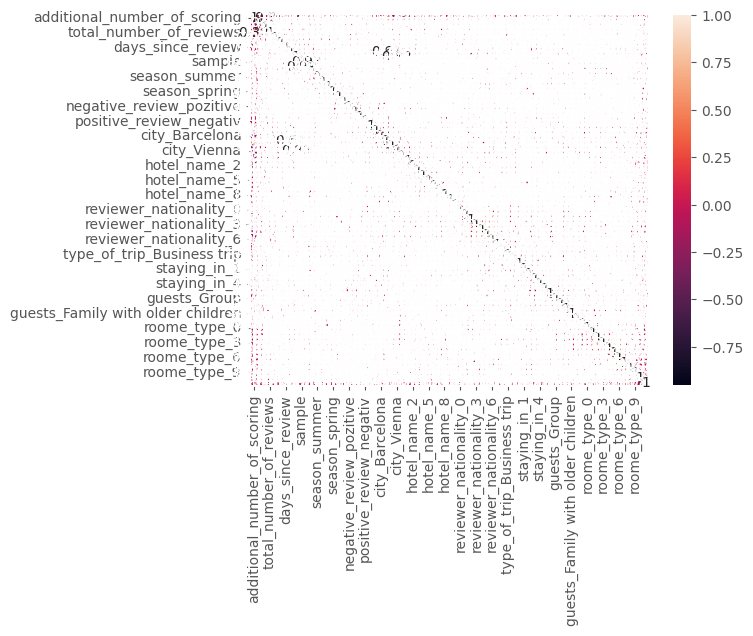

In [154]:
sns.heatmap(data.corr(numeric_only=True), annot=True)

In [155]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    '''Получаем диагональную и нижнюю треугольную пары корреляционной матрицы'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

get_top_abs_correlations(data, 20) 

positive_review_pozitive      positive_review_neutral       0.949818
sample                        reviewer_score                0.931753
type_of_trip_Leisure trip     type_of_trip_Business trip    0.904248
lat                           city_Barcelona                0.844616
lng                           city_Vienna                   0.824914
additional_number_of_scoring  total_number_of_reviews       0.824884
lng                           city_L o n d o n              0.660965
negative_review_negativ       negative_review_neutral       0.650342
lat                           city_L o n d o n              0.611041
reviewer_nationality_5        reviewer_nationality_7        0.537940
type_of_trip_Business trip    guests_Solo traveler          0.528422
negative_review_negativ       negative_review_pozitive      0.525592
type_of_trip_Leisure trip     guests_Solo traveler          0.508686
guests_Couple                 guests_Solo traveler          0.503196
additional_number_of_scoring  city

Если признаки имеют коэффициент корреляции >0.95, то удаляем один из признаков, у которого меньший коэффициент корреляции с целевой переменной
>На этой итерации пока не удаляем никакие признаки

---

## 6. Отбор признаков на основе их важности

In [156]:
data.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'days_since_review',
       'lat', 'lng', 'sample', 'reviewer_score', 'mobile_device',
       'season_summer', 'season_winter', 'season_autumn', 'season_spring',
       'negative_review_negativ', 'negative_review_neutral',
       'negative_review_pozitive', 'positive_review_pozitive',
       'positive_review_neutral', 'positive_review_negativ', 'city_Milan',
       'city_Amsterdam', 'city_Barcelona', 'city_L o n d o n', 'city_Paris',
       'city_Vienna', 'hotel_name_0', 'hotel_name_1', 'hotel_name_2',
       'hotel_name_3', 'hotel_name_4', 'hotel_name_5', 'hotel_name_6',
       'hotel_name_7', 'hotel_name_8', 'hotel_name_9', 'hotel_name_10',
       'reviewer_nationality_0', 'reviewer_nationality_1',
       'reviewer_nationality_2', 'reviewer_nationality_3',
       

### Статистические тесты категориальных признаков $\Chi^2$:

In [157]:
# Исходные данные
X = data.drop(['reviewer_score'], axis=1)
y = data['reviewer_score'].astype('int')

cat_cols = ['mobile_device',
       'season_summer', 'season_winter', 'season_autumn', 'season_spring',
       'negative_review_negativ', 'negative_review_neutral',
       'negative_review_pozitive', 'positive_review_pozitive',
       'positive_review_neutral', 'positive_review_negativ', 'city_Milan',
       'city_Amsterdam', 'city_Barcelona', 'city_L o n d o n', 'city_Paris',
       'city_Vienna', 'hotel_name_0', 'hotel_name_1', 'hotel_name_2',
       'hotel_name_3', 'hotel_name_4', 'hotel_name_5', 'hotel_name_6',
       'hotel_name_7', 'hotel_name_8', 'hotel_name_9', 'hotel_name_10',
       'reviewer_nationality_0', 'reviewer_nationality_1',
       'reviewer_nationality_2', 'reviewer_nationality_3',
       'reviewer_nationality_4', 'reviewer_nationality_5',
       'reviewer_nationality_6', 'reviewer_nationality_7',
       'type_of_trip_Leisure trip', 'type_of_trip_Business trip',
       'type_of_trip_nan', 'staying_in_0', 'staying_in_1', 'staying_in_2',
       'staying_in_3', 'staying_in_4', 'staying_in_5', 'guests_Couple',
       'guests_Group', 'guests_Solo traveler',
       'guests_Family with young children',
       'guests_Family with older children', 'guests_With a pet',
       'guests_Travelers with friends', 'roome_type_0', 'roome_type_1',
       'roome_type_2', 'roome_type_3', 'roome_type_4', 'roome_type_5',
       'roome_type_6', 'roome_type_7', 'roome_type_8', 'roome_type_9',
       'roome_type_10', 'roome_type_11']

# Фильтруем только неотрицательные столбцы (требуется для chi2)
non_negative_cols = []
for col in cat_cols:
    if (X[col] >= 0).all():
        non_negative_cols.append(col)
    else:
        print(f"Предупреждение: столбец {col} содержит отрицательные значения и будет исключён из анализа.")

print(f"Для анализа отобрано {len(non_negative_cols)} категориальных признаков.")

# Вычисляем статистику хи‑квадрат и p‑values
chi2_scores, p_values = chi2(X[non_negative_cols], y)

# Создаём DataFrame с результатами
result_df = pd.DataFrame({
    'Feature': non_negative_cols,
    'Chi2': chi2_scores,
    'p-value': p_values
})

# Сортируем по убыванию значений хи‑квадрат (чтобы сверху были самые значимые)
result_df = result_df.sort_values('Chi2', ascending=False)


Для анализа отобрано 64 категориальных признаков.


C:\Users\PC\AppData\Local\Temp\ipykernel_23236\22338415.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='Chi2', y='Feature', palette='viridis')


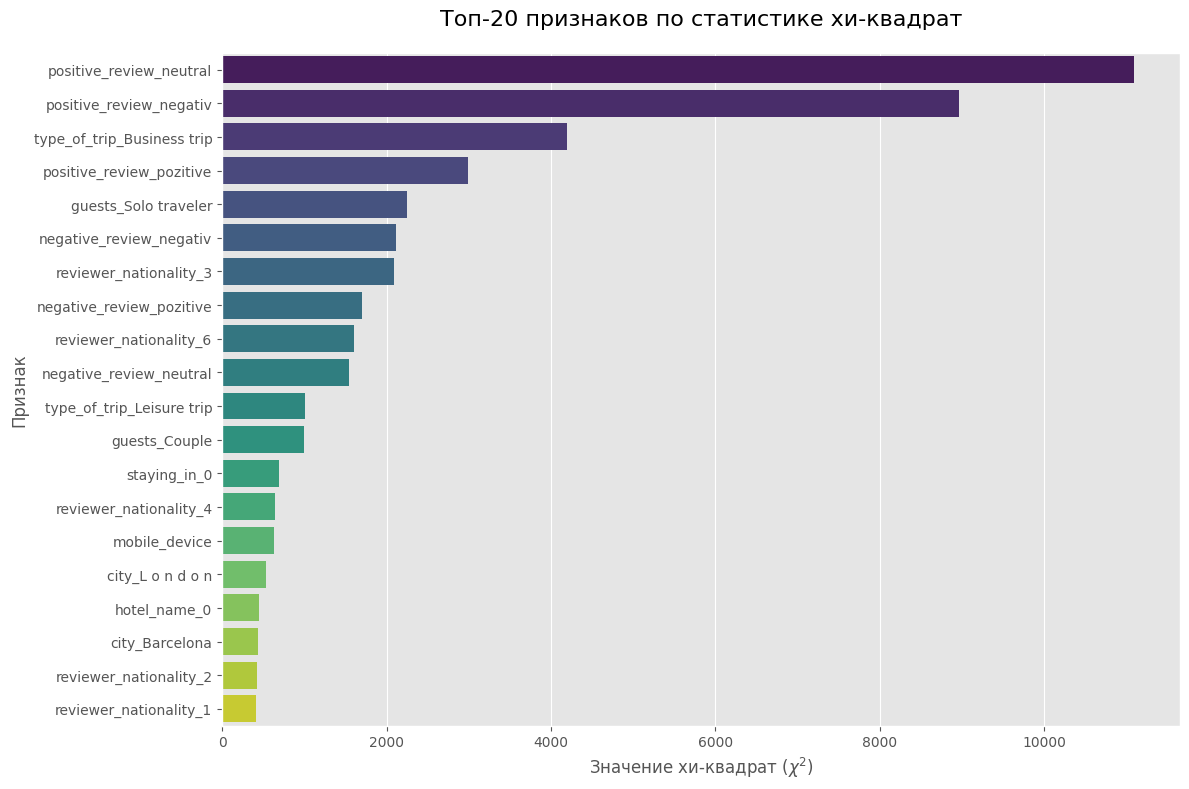

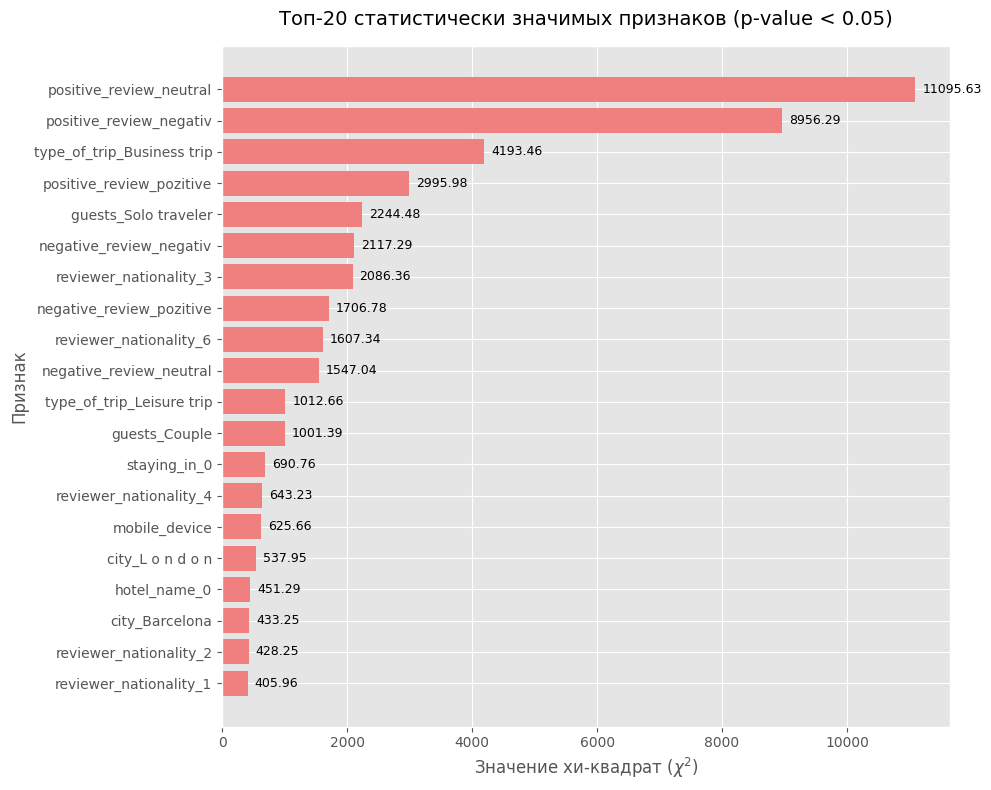

In [160]:
# Визуализация 1: Топ‑20 признаков по значению хи‑квадрат
plt.figure(figsize=(12, 8))
top_20 = result_df.head(20)
sns.barplot(data=top_20, x='Chi2', y='Feature', palette='viridis')
plt.title('Топ‑20 признаков по статистике хи‑квадрат', fontsize=16, pad=20)
plt.xlabel('Значение хи‑квадрат ($\chi^2$)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()


# Визуализация 2: Топ‑20 значимых признаков (p‑value < 0.05)
significant_features = result_df[result_df['p-value'] < 0.05].head(20)
if not significant_features.empty:
    plt.figure(figsize=(10, 8))
    bars = plt.barh(significant_features['Feature'], significant_features['Chi2'], color='lightcoral')
    plt.xlabel('Значение хи‑квадрат ($\chi^2$)', fontsize=12)
    plt.ylabel('Признак', fontsize=12)
    plt.title('Топ‑20 статистически значимых признаков (p‑value < 0.05)', fontsize=14, pad=15)
    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(significant_features['Chi2']) * 0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', ha='left', va='center', fontsize=9)
    plt.gca().invert_yaxis()  # Инвертируем ось Y для лучшего восприятия
    plt.tight_layout()
    plt.show()
else:
    print("Нет признаков с p‑value < 0.05")

In [161]:
# Получаем список топ‑20 признаков (по убыванию χ²)
top_20_features_list = result_df['Feature'].head(20).tolist()

# Получаем список всех признаков из result_df
all_features_list = result_df['Feature'].tolist()


# Находим признаки, которые не вошли в топ‑20 (с 21‑го места и далее)
columns_to_drop = [feature for feature in all_features_list if feature not in top_20_features_list]

display(top_20_features_list)
print(f"Всего признаков для анализа: {len(all_features_list)}")
print(f"Признаков для удаления (с 21‑го места): {len(columns_to_drop)}")


['positive_review_neutral',
 'positive_review_negativ',
 'type_of_trip_Business trip',
 'positive_review_pozitive',
 'guests_Solo traveler',
 'negative_review_negativ',
 'reviewer_nationality_3',
 'negative_review_pozitive',
 'reviewer_nationality_6',
 'negative_review_neutral',
 'type_of_trip_Leisure trip',
 'guests_Couple',
 'staying_in_0',
 'reviewer_nationality_4',
 'mobile_device',
 'city_L o n d o n',
 'hotel_name_0',
 'city_Barcelona',
 'reviewer_nationality_2',
 'reviewer_nationality_1']

Всего признаков для анализа: 64
Признаков для удаления (с 21‑го места): 44


Оставляем 20 признаков с максимальным значением Хи^квадрат

In [162]:
data = data.drop(columns_to_drop, axis = 1)

---

### Статистические тесты числовых признаков ANOVA:

<Axes: >

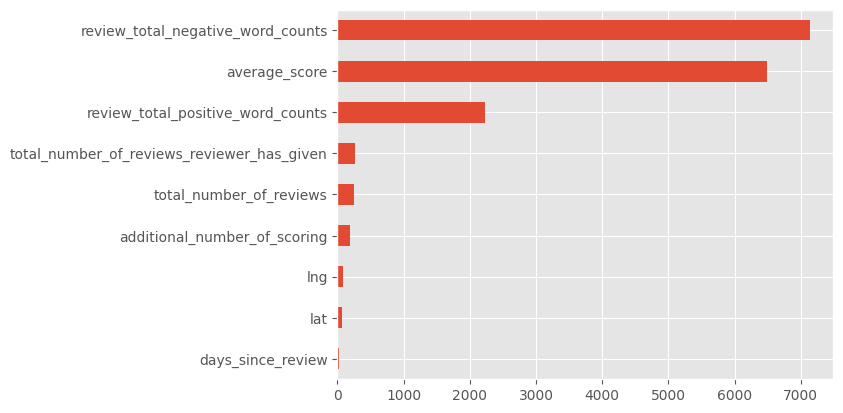

In [164]:

from sklearn.feature_selection import f_classif # anova

X = data.drop(['reviewer_score'], axis = 1)  
y = data['reviewer_score'] 

# Убедимся, что целевая переменная имеет целочисленный тип
y = y.astype('int')

# числовые признаки
num_cols = ['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'days_since_review',
       'lat', 'lng']

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')


In [165]:
dig_columns_to_drop = ['days_since_review','lat','lng']

In [166]:
data = data.drop(dig_columns_to_drop, axis = 1)

---

## 8. Обработка числовых признаков

> Так как в числовых признаках много выбросов, будем использовать нормализацию RobustScaler()

In [167]:
"""
# инициализируем нормализатор RobustScaler
r_scaler = preprocessing.RobustScaler()

# кодируем исходный датасет
data[num_cols] = r_scaler.fit_transform(data[num_cols])

# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации
data[num_cols] = pd.DataFrame(data[num_cols], columns=num_cols)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после RobustScaler')

sns.kdeplot(data[num_cols]['additional_number_of_scoring'], ax=ax1)
sns.kdeplot(data[num_cols]['average_score'], ax=ax1)
sns.kdeplot(data[num_cols]['total_number_of_reviews'], ax=ax1)
sns.kdeplot(data[num_cols]['total_number_of_reviews_reviewer_has_given'], ax=ax1)
sns.kdeplot(data[num_cols]['days_since_review'], ax=ax1)
sns.kdeplot(data[num_cols]['negative_coefficient'], ax=ax1)
sns.kdeplot(data[num_cols]['pozitive_coefficient'], ax=ax1)
"""

"\n# инициализируем нормализатор RobustScaler\nr_scaler = preprocessing.RobustScaler()\n\n# кодируем исходный датасет\ndata[num_cols] = r_scaler.fit_transform(data[num_cols])\n\n# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации\ndata[num_cols] = pd.DataFrame(data[num_cols], columns=num_cols)\n\nfig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))\nax1.set_title('Распределения после RobustScaler')\n\nsns.kdeplot(data[num_cols]['additional_number_of_scoring'], ax=ax1)\nsns.kdeplot(data[num_cols]['average_score'], ax=ax1)\nsns.kdeplot(data[num_cols]['total_number_of_reviews'], ax=ax1)\nsns.kdeplot(data[num_cols]['total_number_of_reviews_reviewer_has_given'], ax=ax1)\nsns.kdeplot(data[num_cols]['days_since_review'], ax=ax1)\nsns.kdeplot(data[num_cols]['negative_coefficient'], ax=ax1)\nsns.kdeplot(data[num_cols]['pozitive_coefficient'], ax=ax1)\n"

In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 28 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515738 non-null  int64  
 1   average_score                               515738 non-null  float64
 2   review_total_negative_word_counts           515738 non-null  int64  
 3   total_number_of_reviews                     515738 non-null  int64  
 4   review_total_positive_word_counts           515738 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  515738 non-null  int64  
 6   sample                                      515738 non-null  int64  
 7   reviewer_score                              515738 non-null  float64
 8   mobile_device                               515738 non-null  int64  
 9   negative_review_negativ                     515738 non-null  int64  
 

---

## Реализация машинного алгоритма и проверка его эффективности

In [169]:
# Теперь выделим тестовую часть
train_data = data.query('sample == 1').drop(['sample'], axis=1)
test_data = data.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

In [170]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [171]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 27), (386803, 27), (386803, 26), (309442, 26), (77361, 26))

In [172]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [173]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [174]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   22.7s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.5s finished


In [175]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAE: 0.918115428082281
MAPE: 0.13139280172312023


<Axes: >

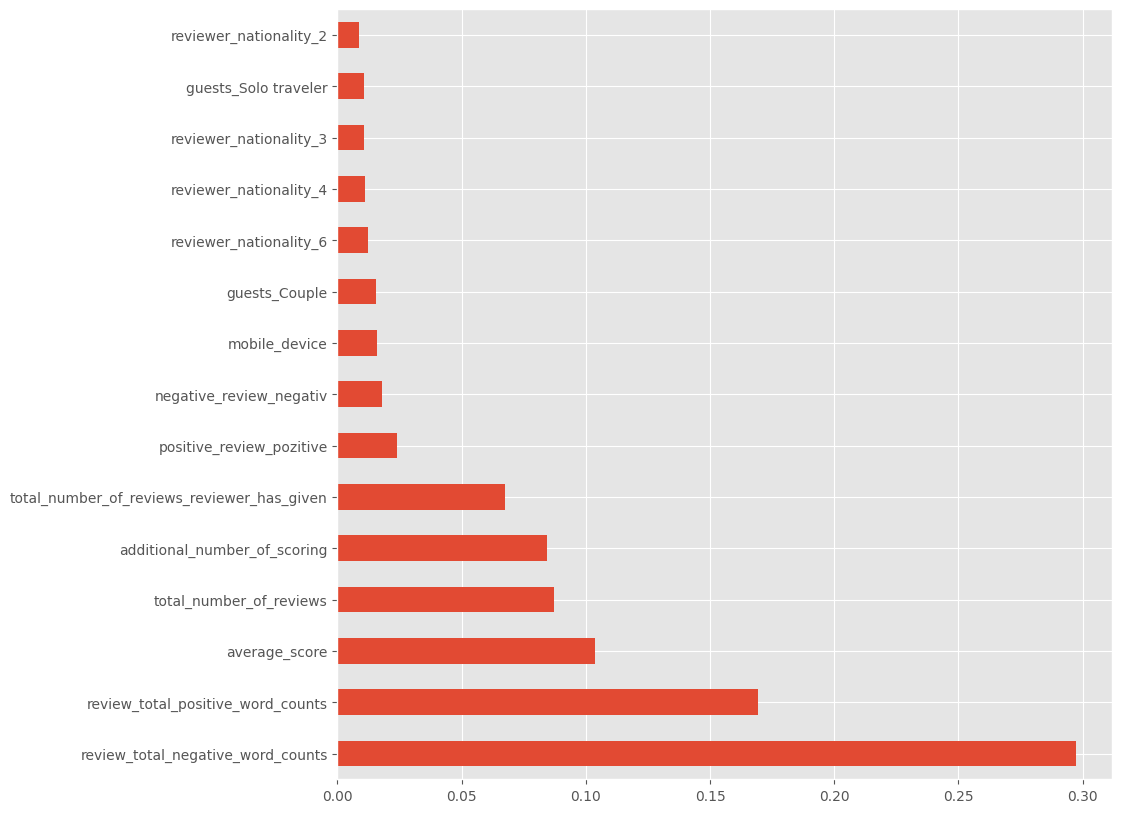

In [176]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')

In [177]:
test_data.sample(10)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,mobile_device,negative_review_negativ,negative_review_neutral,...,reviewer_nationality_1,reviewer_nationality_2,reviewer_nationality_3,reviewer_nationality_4,reviewer_nationality_6,type_of_trip_Leisure trip,type_of_trip_Business trip,staying_in_0,guests_Couple,guests_Solo traveler
57363,1831,8.1,61,7105,15,5,0.0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
34450,398,7.9,11,1521,16,9,0.0,0,1,0,...,0,0,0,0,1,0,1,0,0,1
72314,1322,8.4,3,6117,52,1,0.0,1,1,0,...,0,0,0,0,0,1,0,0,1,0
72564,482,9.0,25,3158,12,1,0.0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
116684,1172,7.8,25,5945,9,3,0.0,1,1,0,...,0,0,0,0,0,1,0,0,1,0
66067,160,8.2,0,1100,6,2,0.0,1,1,0,...,0,0,0,0,0,1,0,0,0,0
4061,954,8.6,0,4426,17,1,0.0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
72032,222,7.5,11,1016,0,13,0.0,1,0,1,...,0,0,0,0,0,1,0,0,0,1
3145,378,8.7,2,1543,7,3,0.0,1,0,1,...,0,0,0,0,0,0,1,0,0,1
71157,107,7.9,9,1503,12,13,0.0,1,1,0,...,0,1,0,0,1,1,0,0,0,0


In [178]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [179]:
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [180]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.9s finished


In [181]:
predict_submission

array([8.583, 7.64 , 8.429, ..., 8.419, 9.616, 7.503])

In [182]:
list(sample_submission)

['reviewer_score', 'id']

In [183]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.583000,488440
1,7.640000,274649
2,8.429000,374688
3,9.582000,404352
4,9.401333,451596
5,9.205000,302161
6,8.319000,317079
7,7.652000,13963
8,8.442000,159785
9,8.330000,195089


---

## Выводы по проекту:

В результате реализации данного проекта мною была проделана работа по реализации машинного алгоритма по предсказанию рейтинга отелей:
1. загружены датасеты train и test
2. данные объединены в единый датасет data
3. проведена работа по обработке признаков, созданию новых признаков
4. Проведена кодировка категориальных признаков
5. построена матрица корреляции для анализа мультиколлинеарности
6. произведен отбор признаковн а основе их важности отдельно для категориальных признаков и числовых
7. сделан задел для нормализации данных, в нашей задаче этого не потребовалось
8. был реализован машинный алгоритм и получен результат его эффективности MAPE: 0.13139280172312023
9. принято участие в соревновании на KAGGLE